In [1]:
import keras
import datasets
import numpy as np
import transformers
import sklearn.metrics
import tensorflow as tf
import tqdm.notebook as tqdm
import sklearn.model_selection
import matplotlib.pyplot as plt

In [2]:
# GPU setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except:
        pass

In [5]:
pip install --upgrade datasets huggingface_hub requests urllib3 certifi

Note: you may need to restart the kernel to use updated packages.


In [6]:
# ========================
# Dataset
# ========================
dataset = datasets.load_dataset('google-research-datasets/go_emotions', name='raw', split='train')

emotions = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity',
    'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
    'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

tokenizer = transformers.AutoTokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

In [7]:
# ========================
# Model
# ========================
def get_name(prefix: str | None = None, suffix: str | None = None, separator: str = '_') -> str | None:
    return prefix and prefix + separator + suffix or suffix or None

In [ ]:
# def get_model(
#     units: int,
#     n_tokens: int,
#     n_labels: int,
#     n_stacks: int = 1,
#     bidirectional: bool = False,
#     name: str | None = None,
#     cell_type: type[keras.layers.Layer] = keras.layers.LSTMCell
# ) -> keras.Model:
#     """Creates a model with RNN architecture for sequence multilabel classification."""
#     # TODO: implement
#     pass

In [8]:
def get_model(
    units: int,
    n_tokens: int,
    n_labels: int,
    n_stacks: int = 1,
    bidirectional: bool = False,
    name: str | None = None,
    cell_type: type[keras.layers.Layer] = keras.layers.LSTMCell
) -> keras.Model:
    """
    Creates a model with RNN architecture for sequence multilabel classification.
    """
    inputs = keras.Input(shape=(None,), dtype="int32", name="input_tokens")

    # Embedding слой: токен -> вектор
    x = keras.layers.Embedding(input_dim=n_tokens, output_dim=units, mask_zero=True)(inputs)

    # Собираем стек RNN
    for i in range(n_stacks):
        rnn_layer = keras.layers.RNN(
            cell_type(units),
            return_sequences=(i < n_stacks - 1)  # если не последний слой, возвращаем последовательность
        )
        if bidirectional:
            rnn_layer = keras.layers.Bidirectional(rnn_layer)
        x = rnn_layer(x)

    # Классификатор
    outputs = keras.layers.Dense(n_labels, activation="sigmoid")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name=name)
    return model


In [ ]:
# # ========================
# # Training
# # ========================
# models = [
#     get_model(
#         units=...,
#         n_tokens=len(tokenizer.get_vocab()),
#         n_labels=len(emotions),
#         name=...,
#         bidirectional=...,
#         n_stacks=...,
#         cell_type=...
#     )
#     for ... in ...
# ]

# for model in models:
#     model.compile(
#         loss=...,  # BinaryCrossentropy(from_logits=True)
#         optimizer=keras.optimizers.Adam(...),
#         metrics=[...]
#     )

# # здесь надо будет подготовить train_dataset и test_dataset

# for train_dataset, test_dataset in datasets:  # TODO: заменить datasets на правильные train/test
#     for model in models:
#         model.fit(train_dataset, validation_data=test_dataset, epochs=...)

In [11]:
print(dataset.column_names)
print(dataset[0])

['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
{'text': 'That game hurt.', 'id': 'eew5j0j', 'author': 'Brdd9', 'subreddit': 'nrl', 'link_id': 't3_ajis4z', 'parent_id': 't1_eew18eq', 'created_utc': 1548381056.0, 'rater_id': 1, 'example_very_unclear': False, 'admiration': 0, 'amusement': 0, 'anger': 0, 'annoyance': 0, 'approval': 0, 'caring': 0, 'confusion': 0, 'curiosity': 0, 'desire': 0, 'disappointment': 0, 'disapproval': 0, 'disgust': 0, 'embarrassment': 0, 'excitement': 0, 'fear': 0, 'gratitude': 0, 'grief': 0, 'joy': 0, 'love': 0, 'nervousness': 0, 'optimism': 0, 'pride': 0, 'realization': 

In [12]:
from sklearn.model_selection import train_test_split
import numpy as np

# Тексты
texts = dataset["text"]

# Собираем матрицу меток (N, 28)
labels = np.stack([dataset[emo] for emo in emotions], axis=1).astype("float32")

print("Texts:", texts[:3])
print("Labels shape:", labels.shape)
print("First example:", labels[0])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# Токенизация
def tokenize(texts, max_length=50):
    return tokenizer(
        texts,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="np"
    )["input_ids"]

X_train_tok = tokenize(X_train)
X_test_tok = tokenize(X_test)

# Переводим в tf.data.Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_tok, y_train)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test_tok, y_test)).batch(32)


Texts: ['That game hurt.', ' >sexuality shouldn’t be a grouping category It makes you different from othet ppl so imo it fits the definition of "grouping" ', "You do right, if you don't care then fuck 'em!"]
Labels shape: (211225, 28)
First example: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0.]


In [13]:
models = [
    get_model(units=64, n_tokens=len(tokenizer.get_vocab()), n_labels=len(emotions),
              name="simple_rnn", bidirectional=False, n_stacks=1, cell_type=keras.layers.LSTMCell),

    get_model(units=64, n_tokens=len(tokenizer.get_vocab()), n_labels=len(emotions),
              name="stacked_rnn", bidirectional=False, n_stacks=2, cell_type=keras.layers.LSTMCell),

    get_model(units=64, n_tokens=len(tokenizer.get_vocab()), n_labels=len(emotions),
              name="bidir_rnn", bidirectional=True, n_stacks=1, cell_type=keras.layers.LSTMCell),

    get_model(units=64, n_tokens=len(tokenizer.get_vocab()), n_labels=len(emotions),
              name="stacked_bidir_rnn", bidirectional=True, n_stacks=2, cell_type=keras.layers.LSTMCell)
]


In [14]:
for model in models:
    model.compile(
        loss=keras.losses.BinaryCrossentropy(),
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        metrics=[
            keras.metrics.AUC(multi_label=True, name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall")
        ]
    )


In [22]:
for model in models:
    print(f"\nTraining {model.name}...")
    model.fit(train_dataset, validation_data=test_dataset, epochs=10)



Training simple_rnn...
Epoch 1/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 136s 26ms/step - auc: 0.5006 - loss: 0.1577 - precision: 0.0500 - recall: 5.0072e-06 - val_auc: 0.5001 - val_loss: 0.1570 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 134s 25ms/step - auc: 0.5326 - loss: 0.1559 - precision: 0.0278 - recall: 1.0014e-05 - val_auc: 0.6428 - val_loss: 0.1466 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 135s 25ms/step - auc: 0.7300 - loss: 0.1347 - precision: 0.6886 - recall: 0.0853 - val_auc: 0.7912 - val_loss: 0.1266 - val_precision: 0.6216 - val_recall: 0.1636
Epoch 4/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 132s 25ms/step - auc: 0.8200 - loss: 0.1205 - precision: 0.6706 - recall: 0.1711 - val_auc: 0.8168 - val_loss: 0.1218 - val_precision: 0.6167 - val_recall: 0.1866
Epoch 5/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 133s 25ms/step - auc: 0.8530 - loss: 0.1131 - precision: 0.6824 - recall: 0.2152 - val_auc

In [ ]:
# ========================
# Evaluation
# ========================
def plot_roc_curve(X: np.ndarray, y: np.ndarray, model: keras.Model, ax: plt.Axes | None = None) -> float:
    """Plots ROC curves for each of the labels (on a single axes) and outputs mean ROC AUC score."""
    # TODO: implement
    pass

def label_text(text: str, model: keras.Model, threshold: float = 0.5, max_length: int | None = None) -> list[str]:
    """Predict emotions for a given text."""
    # TODO: implement
    pass

def plot_emotion_scores(text: str, model: keras.Model, max_length: int | None = None, ax: plt.Axes | None = None):
    """Plot emotion probabilities for given text."""
    # TODO: implement
    pass

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
import tensorflow as tf
from tensorflow import keras

# считаем, что у нас есть tokenizer и emotions (список строк)

def plot_roc_curve(
    X: np.ndarray, 
    y: np.ndarray, 
    model: keras.Model, 
    ax: plt.Axes | None = None
) -> float:
    """Plots ROC curves for each of the labels (on a single axes) and outputs mean ROC AUC score."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    y_pred = model.predict(X, verbose=0)
    n_labels = y.shape[1]
    aucs = []

    for i in range(n_labels):
        fpr, tpr, _ = roc_curve(y[:, i], y_pred[:, i])
        score = auc(fpr, tpr)
        aucs.append(score)
        ax.plot(fpr, tpr, lw=1, alpha=0.7, label=f"{emotions[i]} (AUC={score:.2f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC curves per emotion")
    ax.legend(fontsize=8, loc="best", ncol=2)

    mean_auc = float(np.mean(aucs))
    return mean_auc


def label_text(
    text: str, 
    model: keras.Model, 
    threshold: float = 0.5, 
    max_length: int | None = None
) -> list[str]:
    """Predict emotions for a given text."""
    tokens = tokenizer(
        text, 
        return_tensors="tf", 
        padding="max_length" if max_length else True,
        truncation=True, 
        max_length=max_length
    )

    probs = tf.sigmoid(model(tokens["input_ids"])).numpy()[0]
    preds = [emotions[i] for i, p in enumerate(probs) if p >= threshold]
    return preds


def plot_emotion_scores(
    text: str, 
    model: keras.Model, 
    max_length: int | None = None, 
    ax: plt.Axes | None = None
):
    """Plot emotion probabilities for given text."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    tokens = tokenizer(
        text, 
        return_tensors="tf", 
        padding="max_length" if max_length else True,
        truncation=True, 
        max_length=max_length
    )

    probs = tf.sigmoid(model(tokens["input_ids"])).numpy()[0]
    
    ax.bar(emotions, probs)
    ax.set_xticklabels(emotions, rotation=90)
    ax.set_ylabel("Probability")
    ax.set_title(f"Emotion scores for: {text[:30]}...")
    ax.set_ylim(0, 1)


Mean ROC-AUC: 0.811


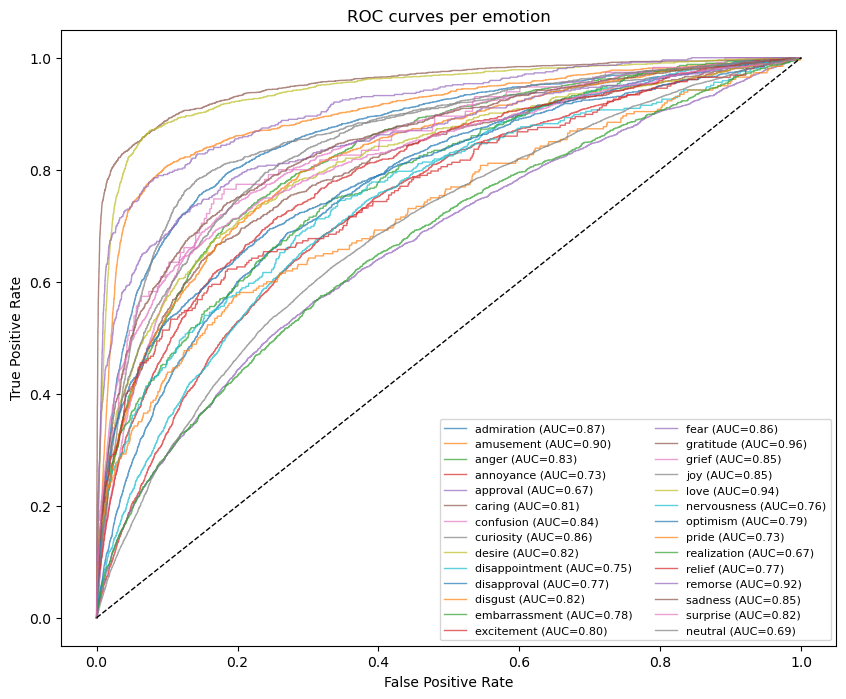

In [24]:
# 1. ROC-кривые для тестовой выборки
fig, ax = plt.subplots(figsize=(10, 8))
mean_auc = plot_roc_curve(X_test_tok, y_test, model, ax=ax)
print(f"Mean ROC-AUC: {mean_auc:.3f}")
plt.show()


In [27]:
# 2. Предсказание эмоций для текста
sample_text = "I am so happy today!"
predicted_labels = label_text(sample_text, model, threshold=0.5, max_length=64)
print("Predicted emotions:", predicted_labels)


Predicted emotions: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


C:\Users\maxim\AppData\Local\Temp\ipykernel_9600\1236541813.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(emotions, rotation=90)


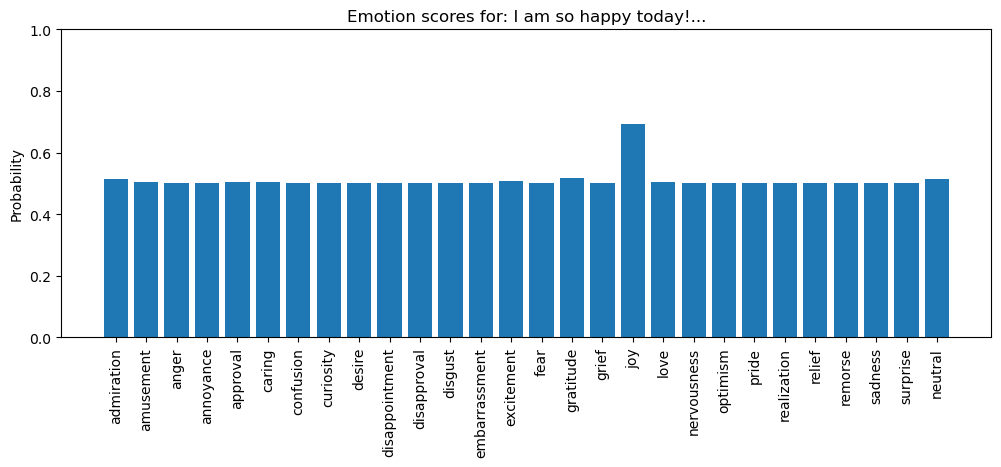

In [28]:
# 3. Визуализация вероятностей эмоций
fig, ax = plt.subplots(figsize=(12, 4))
plot_emotion_scores(sample_text, model, max_length=64, ax=ax)
plt.show()
